# **02_Analisis_exploratorio_EDA**

Desarrollado por: Ing. M. Wara López L.

### Importación de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", palette="viridis")

### Carga del dataset

In [3]:
df = pd.read_csv('dataset_limpio_baterias.csv')

In [4]:
df["Usuario_Gamer"] = df["Usuario_Gamer"].astype("object")

In [5]:
df.head()

,Edad_Bateria,Horas_Uso_Diario,Usuario_Gamer,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
0,5.0,9.797617,0,57884,1267.000000,64.587764,43.887115,84.366245,35.645636,44961.935220,76.923383
1,9.0,7.101557,0,63824,1298.951125,45.542182,36.534144,80.629042,31.782432,46619.665590,73.496153
2,9.0,10.085255,0,79414,1500.000000,64.640516,52.238349,87.853504,32.122879,63343.419989,79.763543
3,5.0,7.946047,0,61142,1153.000000,55.095724,30.535647,69.686012,30.371133,50407.438833,79.742100
4,4.0,9.628460,0,50956,775.491573,60.145756,36.749489,64.734123,27.536232,34757.377982,67.882552


### Resumen general del dataset

In [6]:
df.shape

(1210, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1210 entries, 0 to 1209
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Edad_Bateria              1210 non-null   float64
 1   Horas_Uso_Diario          1210 non-null   float64
 2   Usuario_Gamer             1210 non-null   object 
 3   Capacidad_Diseño          1210 non-null   int64  
 4   Ciclos_Carga              1210 non-null   float64
 5   Uso_CPU                   1210 non-null   float64
 6   Uso_GPU                   1210 non-null   float64
 7   Consumo_Energia           1210 non-null   float64
 8   Temperatura_Promedio      1210 non-null   float64
 9   Capacidad_Carga_Completa  1210 non-null   float64
 10  Salud_Bateria             1210 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 104.1+ KB


In [8]:
df.describe()

,Edad_Bateria,Horas_Uso_Diario,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
count,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000
mean,4.342149,6.446395,62007.465289,984.509254,49.825246,37.014823,69.047414,30.476204,51648.964030,82.846118
std,2.797605,3.147934,10109.535266,519.891900,17.418638,16.283369,21.096995,2.438592,11603.599401,10.069565
min,0.000000,1.002497,45002.000000,0.000000,9.151884,5.000000,20.133013,23.105802,28181.020459,54.356260
25%,2.000000,3.726446,53260.250000,539.750000,36.432784,25.892769,52.947394,29.056738,42713.137063,75.263592
50%,4.000000,6.336366,61782.500000,1145.500000,49.918823,35.230937,68.135488,30.420018,51469.392795,81.254892
75%,7.000000,9.165856,70701.000000,1500.000000,61.170324,43.937879,83.664723,31.926168,60145.820734,91.539939
max,9.000000,11.986722,79959.000000,1500.000000,100.000000,98.339932,137.154936,39.934239,78634.214027,100.000000


In [9]:
print("Dimensiones finales:", df.shape)
print("Valores nulos:", df.isnull().sum().sum())
print("Duplicados:", df.duplicated().sum())

Dimensiones finales: (1210, 11)
Valores nulos: 0
Duplicados: 0


### Correlación de variables

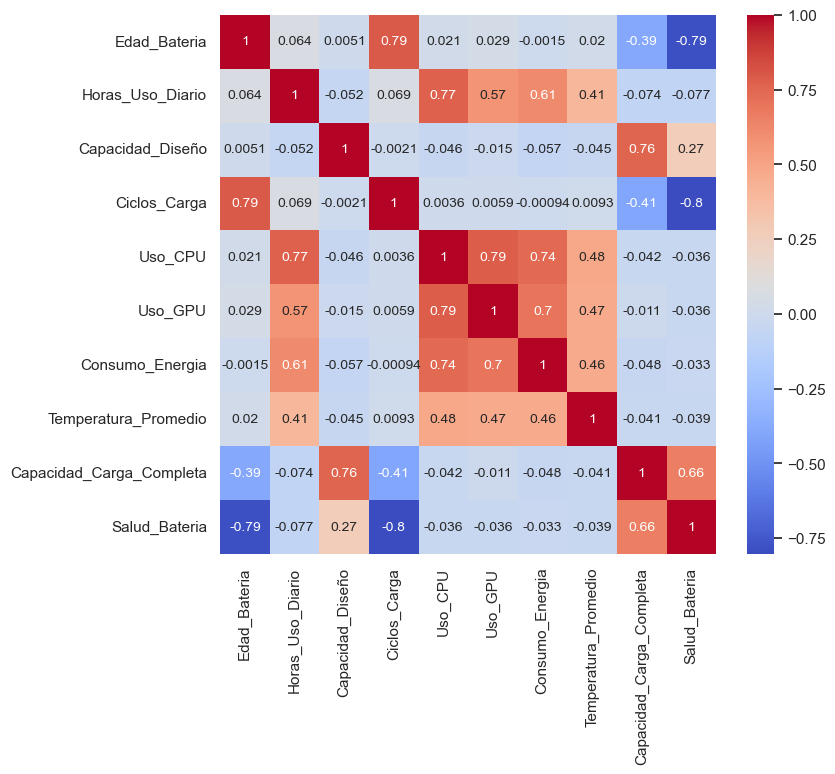

In [10]:
correlacion = df.corr(numeric_only=True)
plt.figure(figsize=(8,7))
sns.heatmap(correlacion,annot=True,cmap="coolwarm",annot_kws={"size":10})
plt.show()

### Distribución de variables

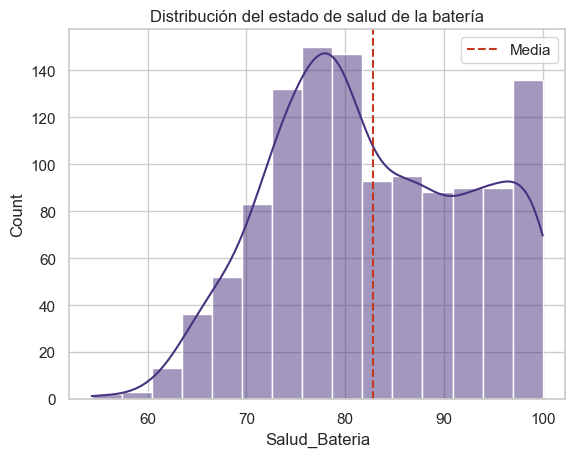

In [11]:
sns.histplot(df["Salud_Bateria"],kde=True).set(title="Distribución del estado de salud de la batería")
plt.axvline(df["Salud_Bateria"].mean(),color="#C4391D",linestyle="--",label="Media")
plt.legend()

La distribución de la salud de la batería evidencia una mayor concentración de registros en valores altos, indicando que la mayoría de los dispositivos mantienen un buen estado de conservación. La curva de densidad muestra una distribución relativamente continua, sin una acumulación significativa de baterías con niveles críticos de degradación.

<Axes: xlabel='Edad_Bateria', ylabel='Salud_Bateria'>

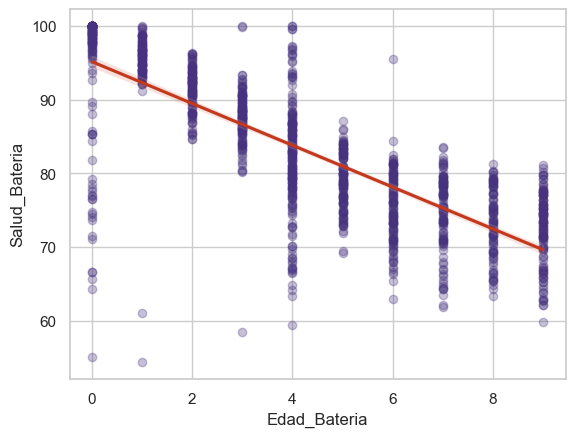

In [12]:
sns.regplot(data=df,x="Edad_Bateria",y="Salud_Bateria",scatter_kws={"alpha":0.3},line_kws={"color":"#C4391D"})

Se aprecia una relación inversa entre la edad de la batería y su nivel de salud. Conforme aumenta la antigüedad del dispositivo, la salud tiende a disminuir, aunque existe cierta dispersión que puede atribuirse a diferencias en los hábitos de uso y carga de cada equipo.

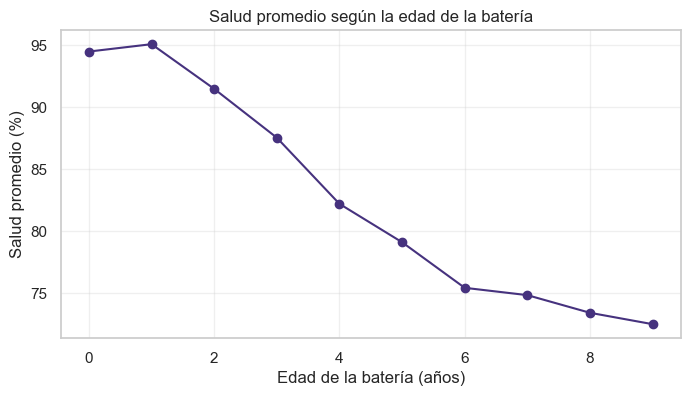

In [13]:
salud_edad = (df.groupby("Edad_Bateria")["Salud_Bateria"].mean())
plt.figure(figsize=(8,4))
plt.plot(salud_edad.index, salud_edad.values, marker="o")
plt.title("Salud promedio según la edad de la batería")
plt.xlabel("Edad de la batería (años)")
plt.ylabel("Salud promedio (%)")
plt.grid(alpha=0.3)
plt.show()

El promedio de salud disminuye de forma gradual conforme aumenta la edad de la batería. Esta tendencia confirma que el envejecimiento constituye uno de los principales factores asociados a la pérdida de capacidad de almacenamiento energético.

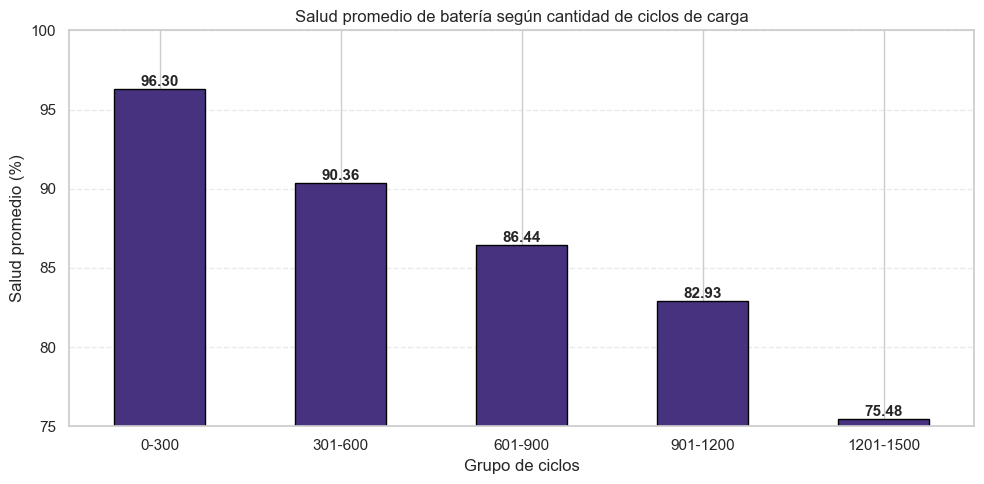

In [14]:
bins = [0, 300, 600, 900, 1200, 1500]
labels = ["0-300", "301-600", "601-900", "901-1200", "1201-1500"]

df["Grupo_Ciclos"] = pd.cut(df["Ciclos_Carga"],bins=bins,labels=labels,include_lowest=True)
salud = df.groupby("Grupo_Ciclos", observed=True)["Salud_Bateria"].mean()

ax = salud.plot(kind="bar",figsize=(10,5),edgecolor="black")

for i, valor in enumerate(salud):
    ax.text(i,valor + 0.2,f"{valor:.2f}",ha="center",fontsize=11,fontweight="bold")

plt.title("Salud promedio de batería según cantidad de ciclos de carga")
plt.xlabel("Grupo de ciclos")
plt.ylabel("Salud promedio (%)")
plt.ylim(75, 100)     
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

La salud promedio de la batería disminuye conforme aumenta el número de ciclos de carga. Este comportamiento refleja el desgaste acumulativo producido por los procesos repetitivos de carga y descarga, evidenciando una degradación progresiva de la capacidad de la batería.

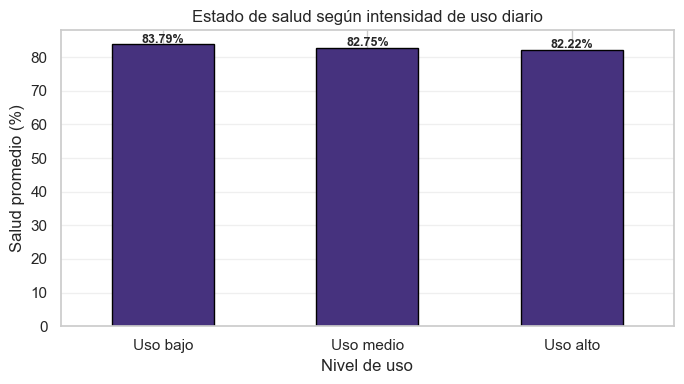

In [15]:
df["Grupo_Uso"] = pd.cut(df["Horas_Uso_Diario"], bins=[0,4,8,12], labels=["Uso bajo","Uso medio","Uso alto"])
salud_grupo = df.groupby("Grupo_Uso", observed=True)["Salud_Bateria"].mean()

plt.figure(figsize=(7,4))
ax = salud_grupo.plot(kind="bar", edgecolor="black")

for i, valor in enumerate(salud_grupo):
    ax.text(i, valor + 0.5, f"{valor:.2f}%", ha="center", fontsize=9, fontweight="bold")

plt.title("Estado de salud según intensidad de uso diario")
plt.xlabel("Nivel de uso")
plt.ylabel("Salud promedio (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

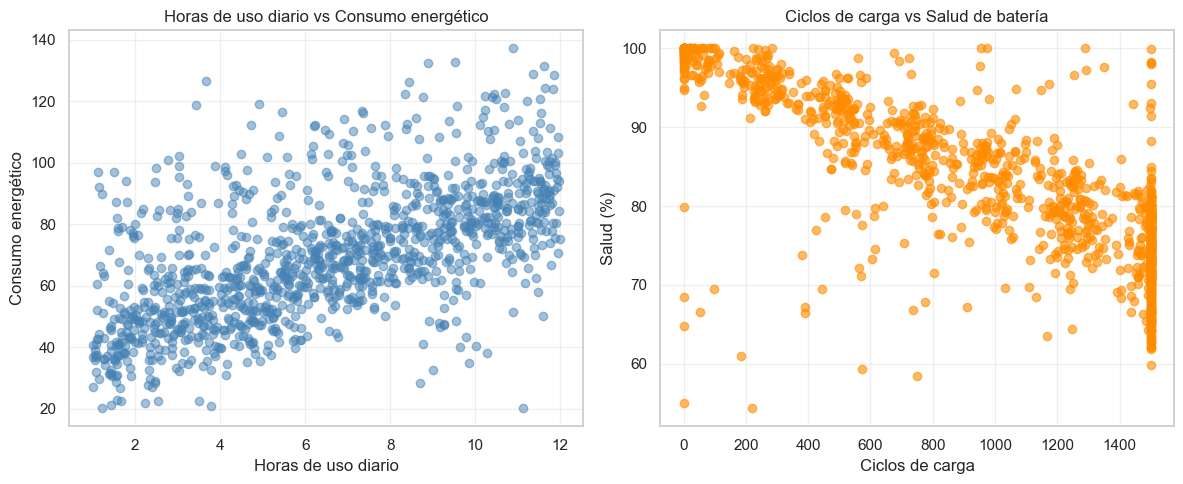

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(df["Horas_Uso_Diario"], df["Consumo_Energia"], alpha=0.5, color="steelblue")
plt.title("Horas de uso diario vs Consumo energético")
plt.xlabel("Horas de uso diario")
plt.ylabel("Consumo energético")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.scatter(df["Ciclos_Carga"], df["Salud_Bateria"], alpha=0.6, color="darkorange")
plt.title("Ciclos de carga vs Salud de batería")
plt.xlabel("Ciclos de carga")
plt.ylabel("Salud (%)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Existe una relación positiva entre las horas de uso diario y el consumo energético. En términos generales, los dispositivos utilizados durante más tiempo presentan un mayor consumo de energía, aunque la dispersión observada indica que otros factores también influyen en dicho consumo.

Se evidencia una relación negativa entre el número de ciclos de carga y la salud de la batería. A medida que aumenta la cantidad de ciclos realizados, la capacidad disponible disminuye progresivamente, lo que coincide con el comportamiento esperado de las baterías recargables.

In [17]:
df.groupby("Usuario_Gamer")[["Uso_CPU","Uso_GPU","Consumo_Energia","Temperatura_Promedio","Salud_Bateria"]].mean().round(2)

,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Salud_Bateria
Usuario_Gamer,,,,,
0,47.23,33.32,65.90,30.24,82.82
1,72.74,69.71,96.87,32.56,83.05


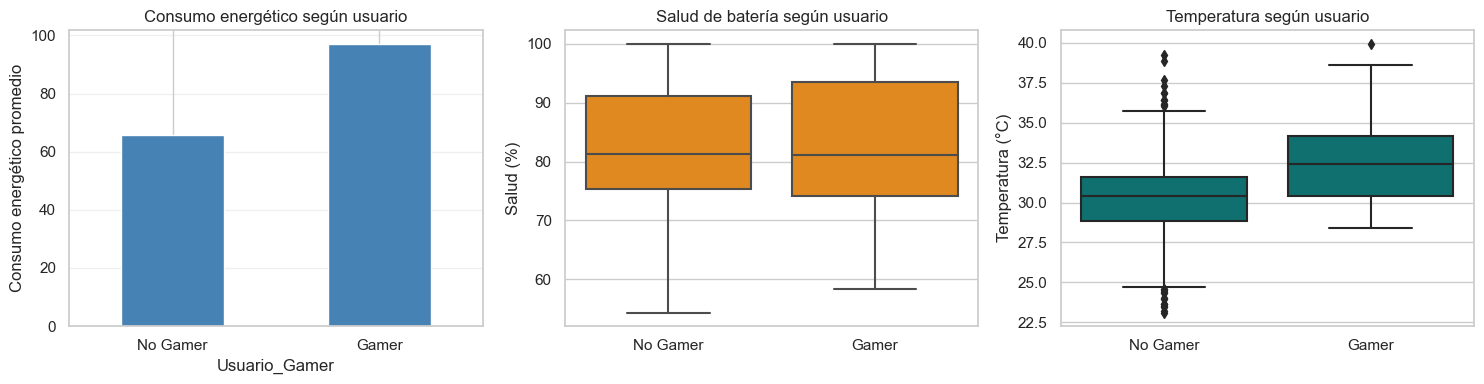

In [18]:
plt.figure(figsize=(15,4))
# Consumo energético promedio
plt.subplot(1,3,1)
consumo_usuario = df.groupby("Usuario_Gamer")["Consumo_Energia"].mean()
consumo_usuario.plot(kind="bar", color="steelblue")
plt.xticks([0,1], ["No Gamer","Gamer"], rotation=0)
plt.ylabel("Consumo energético promedio")
plt.title("Consumo energético según usuario")
plt.grid(axis="y", alpha=0.3)
# Salud de batería
plt.subplot(1,3,2)
sns.boxplot(data=df, x="Usuario_Gamer", y="Salud_Bateria", color="darkorange")
plt.xticks([0,1], ["No Gamer","Gamer"])
plt.xlabel("")
plt.ylabel("Salud (%)")
plt.title("Salud de batería según usuario")
# Temperatura promedio
plt.subplot(1,3,3)
sns.boxplot(data=df, x="Usuario_Gamer", y="Temperatura_Promedio", color="teal")
plt.xticks([0,1], ["No Gamer","Gamer"])
plt.xlabel("")
plt.ylabel("Temperatura (°C)")
plt.title("Temperatura según usuario")


plt.tight_layout()
plt.show()

Los usuarios clasificados como Gamer presentan un consumo energético promedio superior al de los usuarios no gamers. Este resultado es consistente con el uso de aplicaciones de mayor demanda computacional, como videojuegos y software gráfico.

La temperatura promedio registrada en dispositivos utilizados por usuarios gamer tiende a ser superior respecto a los usuarios no gamers, lo que puede estar relacionado con una mayor carga de procesamiento y un incremento del consumo energético durante el uso.

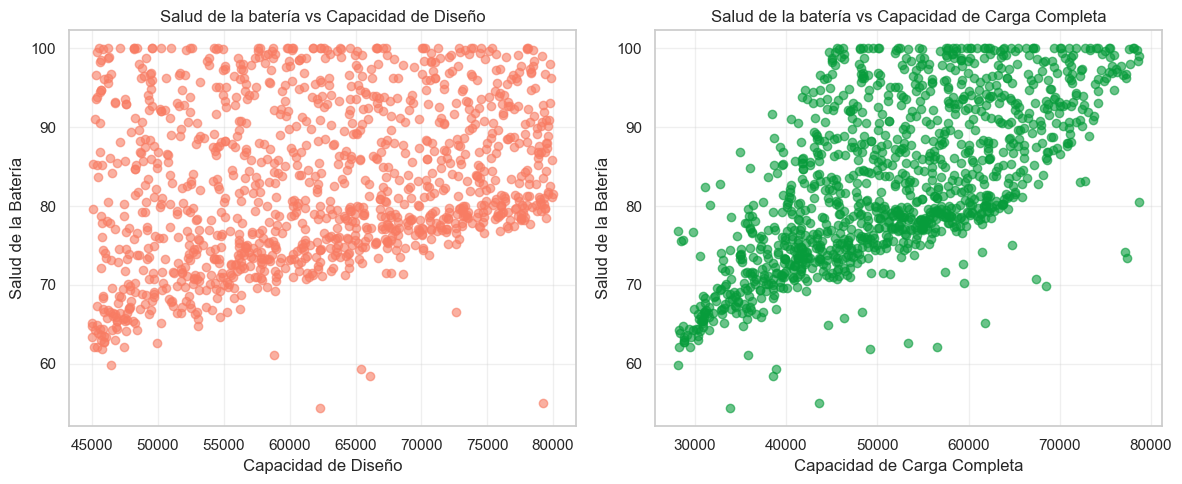

In [19]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(df["Capacidad_Diseño"], df["Salud_Bateria"], alpha=0.6, color="#F87C63")
plt.title("Salud de la batería vs Capacidad de Diseño")
plt.xlabel("Capacidad de Diseño")
plt.ylabel("Salud de la Batería")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.scatter(df["Capacidad_Carga_Completa"], df["Salud_Bateria"], alpha=0.6, color="#079C3B")
plt.title("Salud de la batería vs Capacidad de Carga Completa")
plt.xlabel("Capacidad de Carga Completa")
plt.ylabel("Salud de la Batería")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

No se aprecia una relación claramente definida entre la capacidad de diseño y la salud de la batería. Esto indica que la capacidad nominal establecida por el fabricante no determina directamente el nivel de degradación, el cual depende principalmente del uso y del envejecimiento.

Se observa una relación positiva entre la capacidad de carga completa y la salud de la batería. Las baterías capaces de almacenar una mayor cantidad de energía suelen presentar mejores niveles de salud, lo que resulta coherente al tratarse de variables estrechamente relacionadas.

### Capacidad retenida de batería

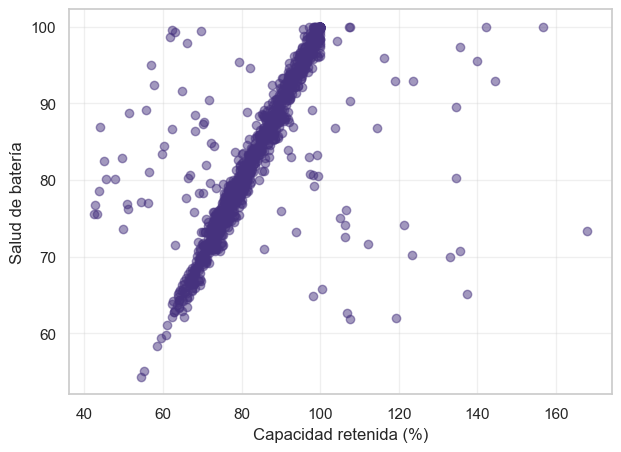

In [20]:
df["Capacidad_Retenida"] = (df["Capacidad_Carga_Completa"] / df["Capacidad_Diseño"]) * 100
plt.figure(figsize=(7,5))
plt.scatter(df["Capacidad_Retenida"],df["Salud_Bateria"],alpha=.5)

plt.xlabel("Capacidad retenida (%)")
plt.ylabel("Salud de batería")
plt.grid(alpha=.3)
plt.show()

Se evidencia una relación positiva entre la capacidad retenida y la salud de la batería. Los dispositivos que conservan un mayor porcentaje de su capacidad original presentan, en general, mejores niveles de salud, lo que confirma que la capacidad retenida constituye un buen indicador del estado de conservación de la batería.

In [21]:
def clasificar_capacidad(x):
    if x >= 90:
        return "Excelente"
    elif x >= 70:
        return "Moderada"
    else:
        return "Degradada"

df["Estado_Capacidad"] = df["Capacidad_Retenida"].apply(clasificar_capacidad)

In [22]:
df["Estado_Capacidad"].value_counts()

Moderada     705
Excelente    366
Degradada    139
Name: Estado_Capacidad, dtype: int64

In [23]:
df.groupby("Estado_Capacidad")["Salud_Bateria"].agg(["count","mean","min","max"])

,count,mean,min,max
Estado_Capacidad,,,,
Degradada,139,70.899760,54.356260,99.507631
Excelente,366,93.902366,61.858627,100.000000
Moderada,705,79.461660,68.744432,95.360691


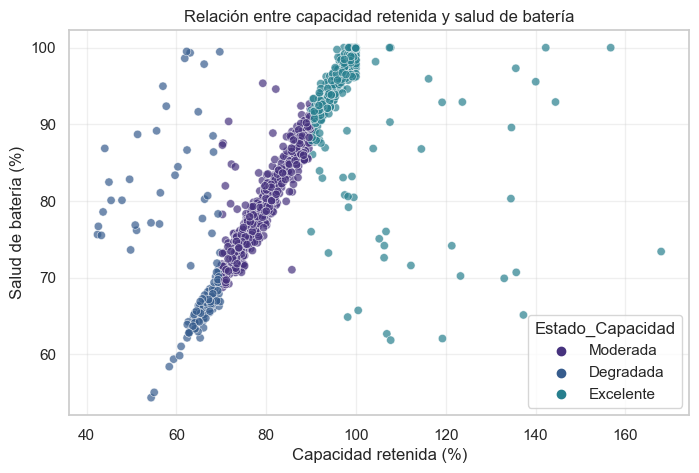

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="Capacidad_Retenida",y="Salud_Bateria",hue="Estado_Capacidad",alpha=0.7)
plt.xlabel("Capacidad retenida (%)")
plt.ylabel("Salud de batería (%)")
plt.title("Relación entre capacidad retenida y salud de batería")
plt.grid(alpha=.3)
plt.show()

In [25]:
df.groupby("Estado_Capacidad")["Ciclos_Carga"].mean()

Estado_Capacidad
Degradada    1265.091783
Excelente     426.557101
Moderada     1218.848994
Name: Ciclos_Carga, dtype: float64

La clasificación por estado de capacidad permite distinguir claramente grupos de baterías con diferentes niveles de conservación. Se observa que las baterías clasificadas con una mayor capacidad retenida concentran los valores más altos de salud, mientras que aquellas con menor capacidad retenida presentan una degradación más evidente. Esta representación facilita la interpretación del estado general de las baterías y respalda la utilidad de la variable derivada creada durante el análisis.